<a href="https://colab.research.google.com/github/Aghil-hub/daily-demand-forecasting-logistics/blob/main/Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand Forecasting
This analysis develops a daily demand forecasting model for a Brazilian logistics company using the UC Irvine “Daily Demand Forecasting Orders” dataset. The objective is to predict total daily orders based on operational drivers and calendar effects, and to evaluate model performance using Root Mean Squared Prediction Error (RMSPE) over repeated 80/20 train–test splits.

We follow a structured approach:
1. Exploratory data analysis to understand demand patterns
2. Feature selection to identify the most informative predictors
3. Estimation of both linear regression and Random Forest models.

The results are then compared in terms of accuracy, stability, and interpretability to inform which model is most suitable for managerial decision‑making in logistics operations

## **1. Setup**



In [1]:
# Load required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Load data from CSV file
df = pd.read_csv('Daily_Demand_Forecasting_Orders.csv',delimiter=';')

In [3]:
# Preview the first five rows
df.head()

,"Week of the month (first week, second, third, fourth or fifth week",Day of the week (Monday to Friday),Non-urgent order,Urgent order,Order type A,Order type B,Order type C,Fiscal sector orders,Orders from the traffic controller sector,Banking orders (1),Banking orders (2),Banking orders (3),Target (Total orders)
0,1,4,316.307,223.270,61.543,175.586,302.448,0.000,65556,44914,188411,14793,539.577
1,1,5,128.633,96.042,38.058,56.037,130.580,0.000,40419,21399,89461,7679,224.675
2,1,6,43.651,84.375,21.826,25.125,82.461,1.386,11992,3452,21305,14947,129.412
3,2,2,171.297,127.667,41.542,113.294,162.284,18.156,49971,33703,69054,18423,317.120
4,2,3,90.532,113.526,37.679,56.618,116.220,6.459,48534,19646,16411,20257,210.517


## **2. Exploratory Data Analysis (EDA)**

### 2.1 Data sanity checks

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 13 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   Week of the month (first week, second, third, fourth or fifth week  60 non-null     int64  
 1   Day of the week (Monday to Friday)                                  60 non-null     int64  
 2   Non-urgent order                                                    60 non-null     float64
 3   Urgent order                                                        60 non-null     float64
 4   Order type A                                                        60 non-null     float64
 5   Order type B                                                        60 non-null     float64
 6   Order type C                                                        60 non-null     float64
 7   Fiscal sector order

There are no missing values in this dataset

In [5]:
df.describe()

,"Week of the month (first week, second, third, fourth or fifth week",Day of the week (Monday to Friday),Non-urgent order,Urgent order,Order type A,Order type B,Order type C,Fiscal sector orders,Orders from the traffic controller sector,Banking orders (1),Banking orders (2),Banking orders (3),Target (Total orders)
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,3.016667,4.033333,172.554933,118.920850,52.112217,109.229850,139.531250,77.396133,44504.350000,46640.833333,79401.483333,23114.633333,300.873317
std,1.282102,1.401775,69.505788,27.170929,18.829911,50.741388,41.442932,186.502470,12197.905134,45220.736293,40504.420041,13148.039829,89.602041
min,1.000000,2.000000,43.651000,77.371000,21.826000,25.125000,74.372000,0.000000,11992.000000,3452.000000,16411.000000,7679.000000,129.412000
25%,2.000000,3.000000,125.348000,100.888000,39.456250,74.916250,113.632250,1.243250,34994.250000,20130.000000,50680.500000,12609.750000,238.195500
50%,3.000000,4.000000,151.062500,113.114500,47.166500,99.482000,127.990000,7.831500,44312.000000,32527.500000,67181.000000,18011.500000,288.034500
75%,4.000000,5.000000,194.606500,132.108250,58.463750,132.171000,160.107500,20.360750,52111.750000,45118.750000,94787.750000,31047.750000,334.237250
max,5.000000,6.000000,435.304000,223.270000,118.178000,267.342000,302.448000,865.000000,71772.000000,210508.000000,188411.000000,73839.000000,616.453000


### 2.2 Target variable (total orders) distribution and time patterns

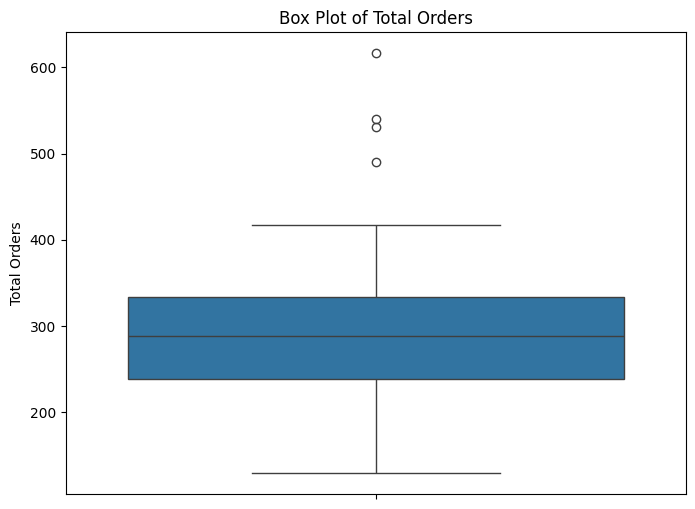

In [6]:
# Boxplot of target to check for outliers
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Target (Total orders)'])
plt.title('Box Plot of Total Orders')
plt.ylabel('Total Orders')
plt.show()

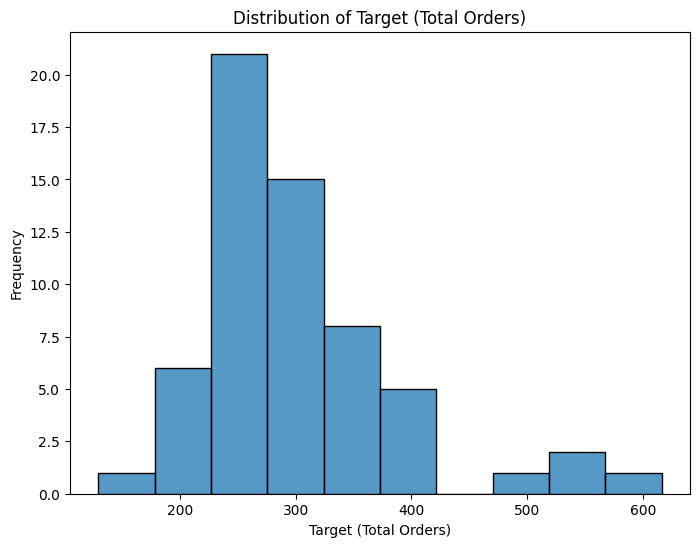

In [7]:
# Histogram of target to inspect distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['Target (Total orders)'])
plt.title('Distribution of Target (Total Orders)')
plt.xlabel('Target (Total Orders)')
plt.ylabel('Frequency')
plt.show()

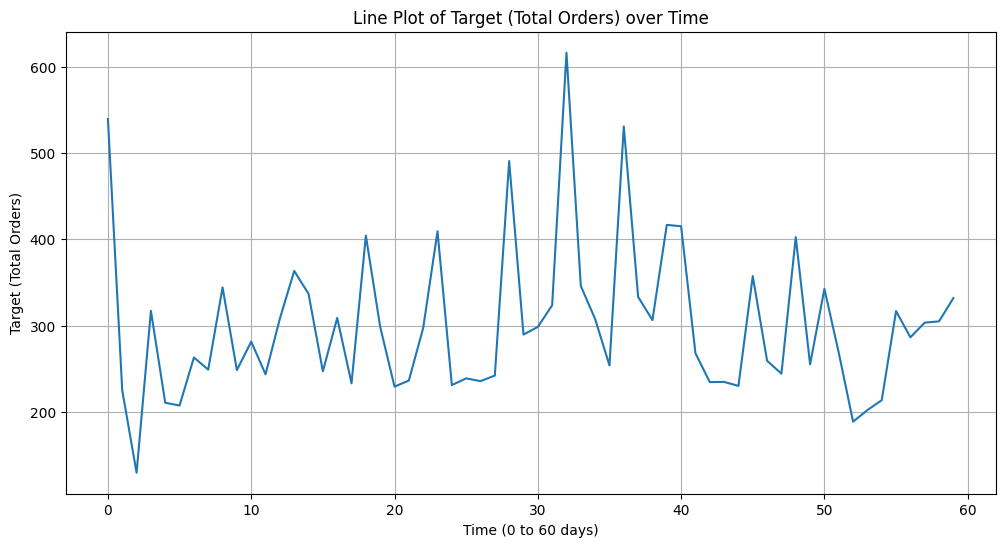

In [8]:
# Check for cyclicity of target
plt.figure(figsize=(12, 6))
sns.lineplot(x=df.index, y='Target (Total orders)', data=df)
plt.title('Line Plot of Target (Total Orders) over Time')
plt.xlabel('Time (0 to 60 days)')
plt.ylabel('Target (Total Orders)')
plt.grid(True)
plt.show()

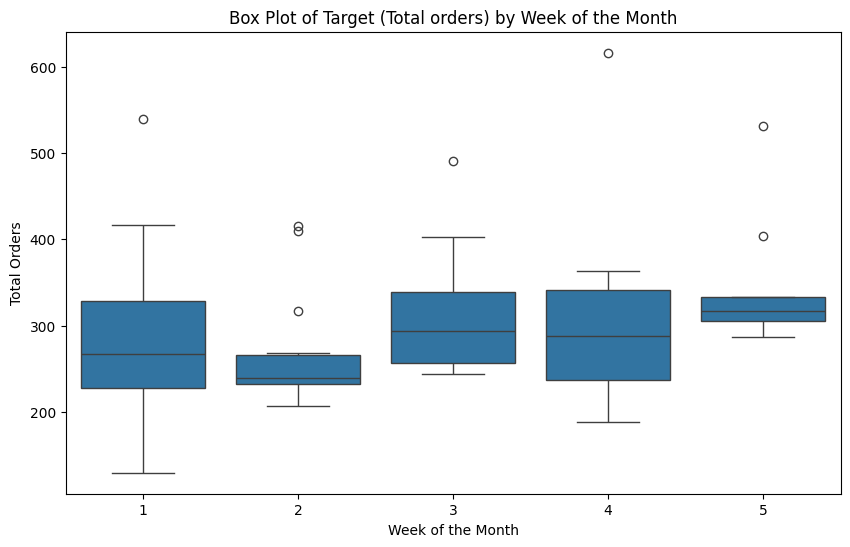

In [9]:
# Boxplot of target by week of the month
plt.figure(figsize=(10, 6))
sns.boxplot(x='Week of the month (first week, second, third, fourth or fifth week', y='Target (Total orders)', data=df)
plt.title('Box Plot of Target (Total orders) by Week of the Month')
plt.xlabel('Week of the Month')
plt.ylabel('Total Orders')
plt.show()

The distribution of total orders is broadly similar across weeks of the month, indicating limited week-of-month effects on demand.

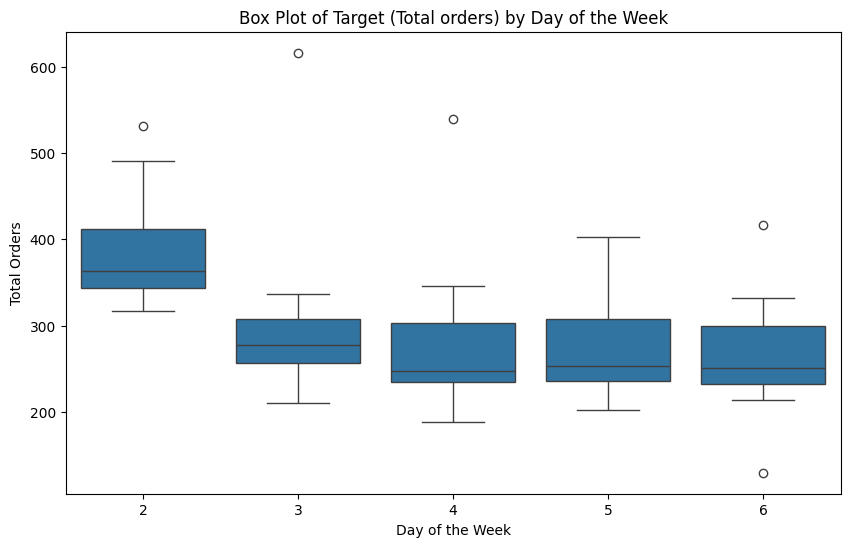

In [10]:
# Boxplot of target by day of the week
plt.figure(figsize=(10, 6))
sns.boxplot(x='Day of the week (Monday to Friday)', y='Target (Total orders)', data=df)
plt.title('Box Plot of Target (Total orders) by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Orders')
plt.show()

In [11]:
# Filter data for Day 2
day_2_orders = df[df['Day of the week (Monday to Friday)'] == 2]['Target (Total orders)']

# Filter data for other days
other_days_orders = df[df['Day of the week (Monday to Friday)'] != 2]['Target (Total orders)']

# Perform independent t-test
t_statistic, p_value = stats.ttest_ind(day_2_orders, other_days_orders, alternative='greater') # Assuming unequal variances

print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

T-statistic: 4.127
P-value: 0.000


The distribution of total orders across the days of the week is similar for all days except for the second day where it is **significantly** higher than other days

### 2.3 Correlation Analysis



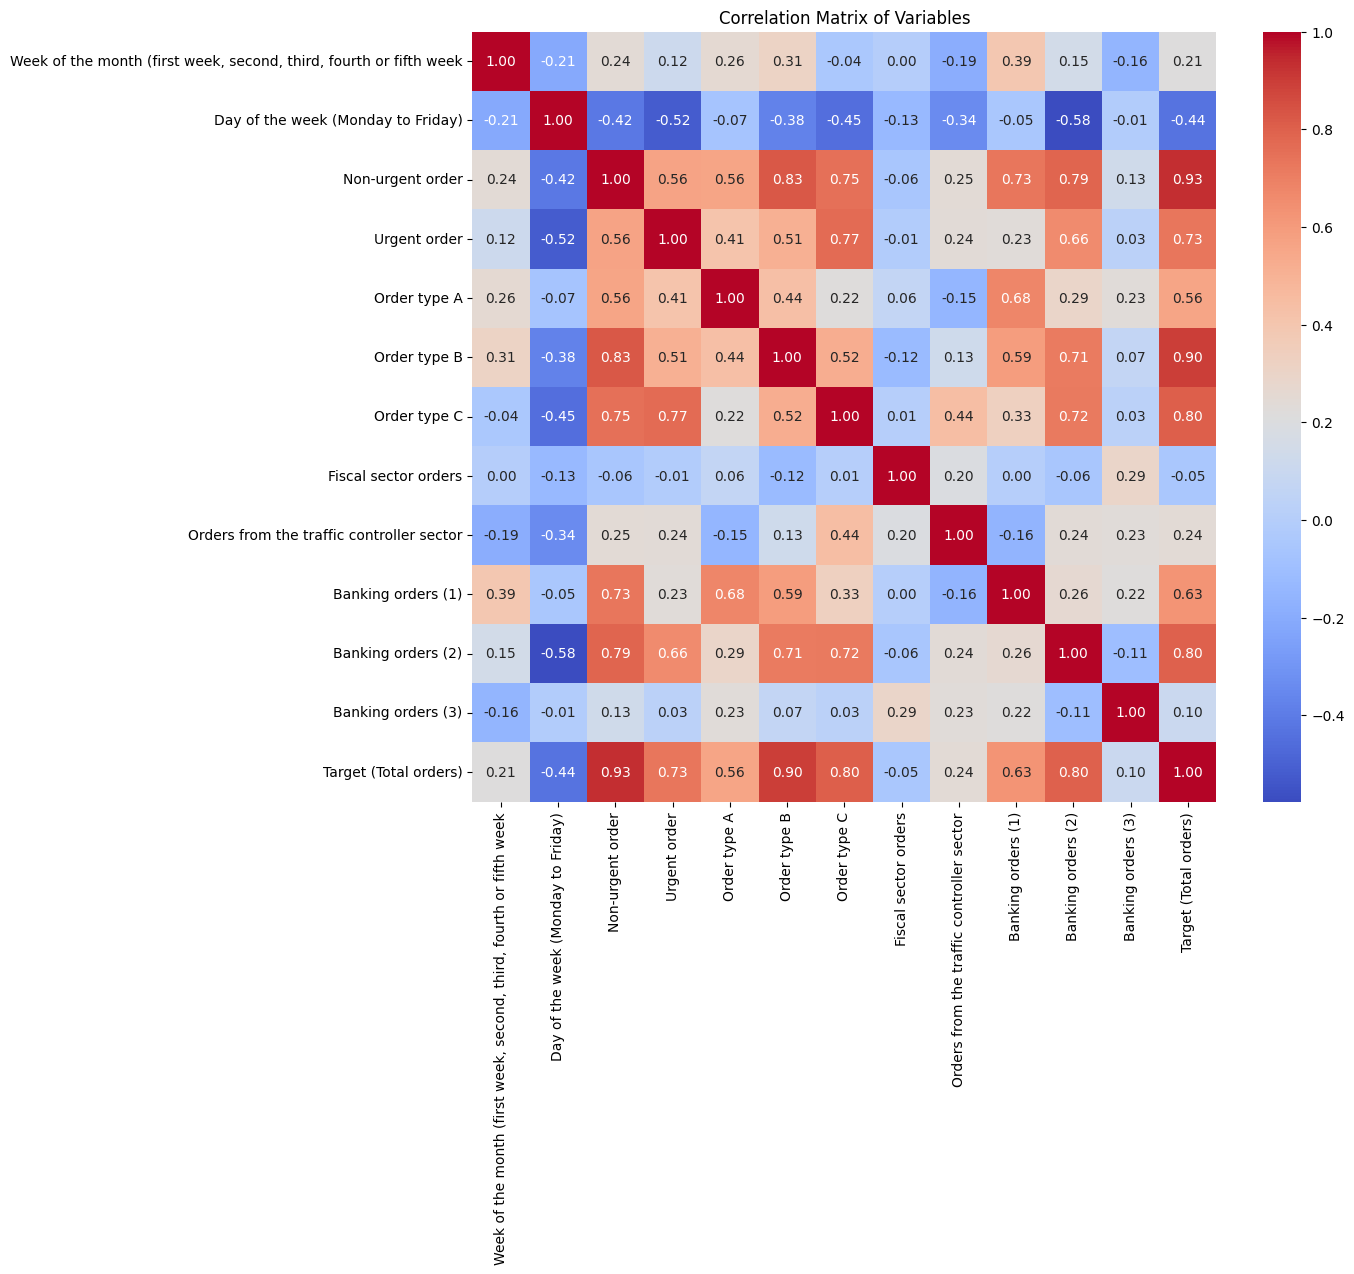

In [12]:
# Correlation Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Variables')
plt.show()

The five variables most strongly correlated with total orders are:

1.   Non-urgent order
2.   Order type B
3.   Order type C
4.   Banking orders (2)
5.   Urgent order

These variables are also highly inter‑correlated, with Order type B, Order type C, and Banking orders (2) strongly related to Non‑urgent and Urgent orders, **indicating substantial multicollinearity**.


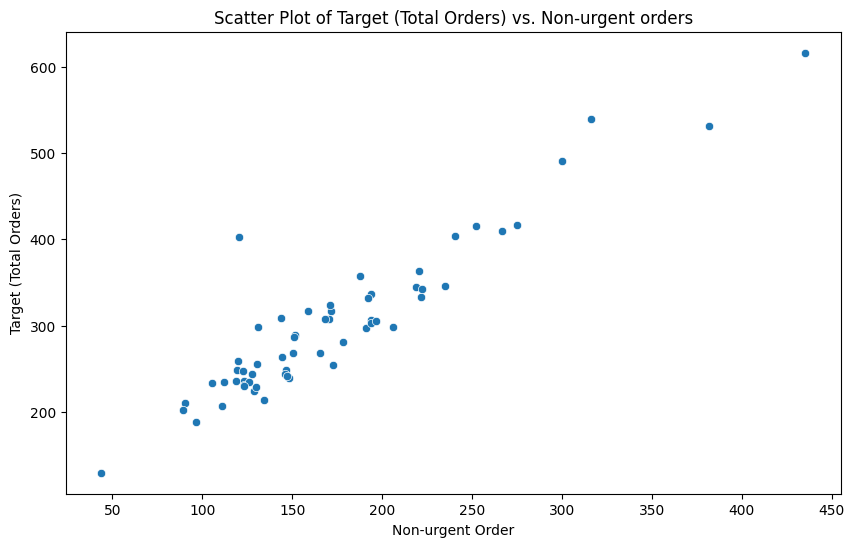

In [13]:
# Scatterplot: Total orders vs Non-urgent order
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Non-urgent order', y='Target (Total orders)', data=df)
plt.title('Scatter Plot of Target (Total Orders) vs. Non-urgent orders')
plt.xlabel('Non-urgent Order')
plt.ylabel('Target (Total Orders)')
plt.show()

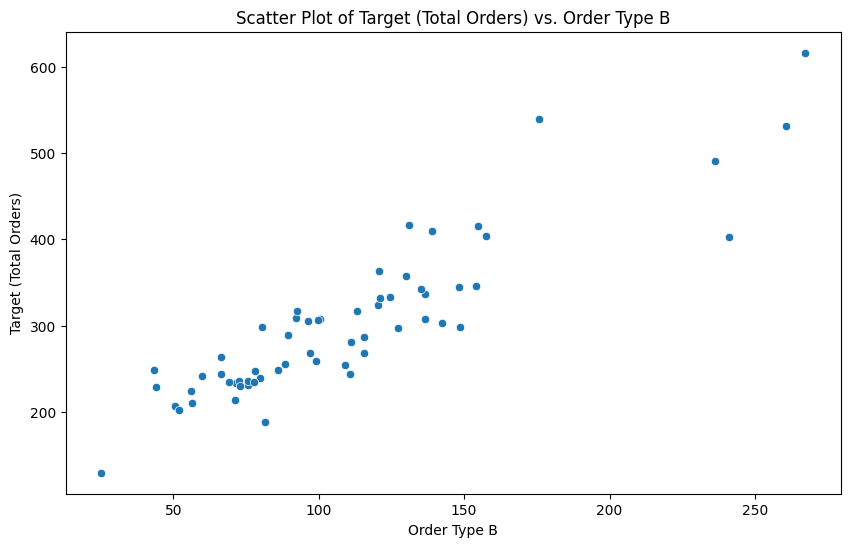

In [14]:
# Scatterplot: Total orders vs Order Type B
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Order type B', y='Target (Total orders)', data=df)
plt.title('Scatter Plot of Target (Total Orders) vs. Order Type B')
plt.xlabel('Order Type B')
plt.ylabel('Target (Total Orders)')
plt.show()

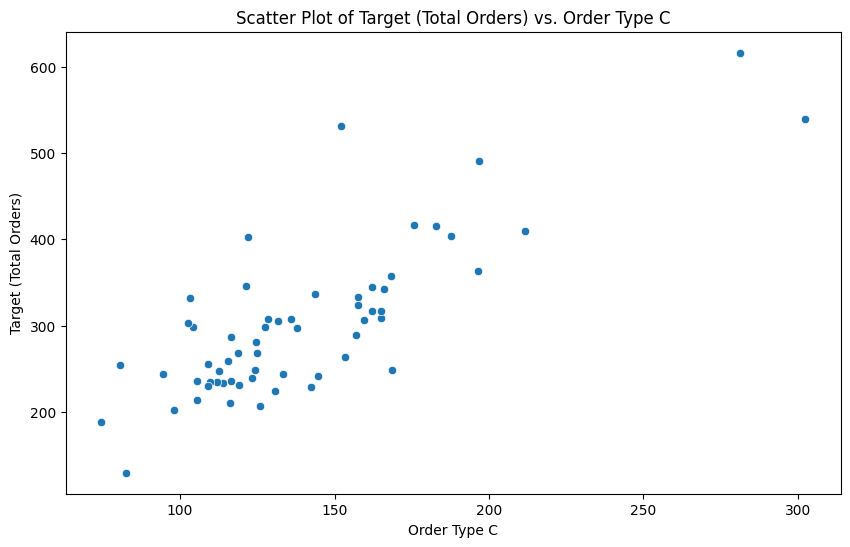

In [15]:
# Scatterplot: Total orders vs Order Type C
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Order type C', y='Target (Total orders)', data=df)
plt.title('Scatter Plot of Target (Total Orders) vs. Order Type C')
plt.xlabel('Order Type C')
plt.ylabel('Target (Total Orders)')
plt.show()

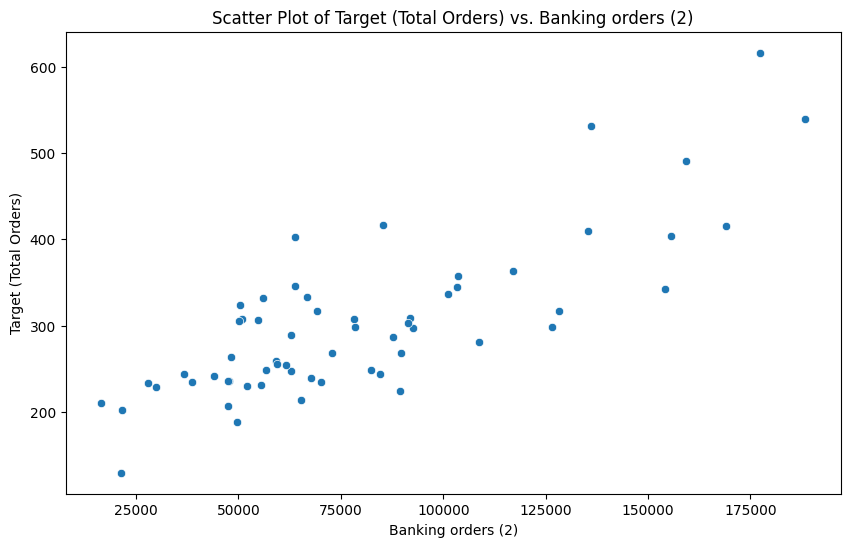

In [16]:
# Scatterplot: Total orders vs Banking orders (2)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Banking orders (2)', y='Target (Total orders)', data=df)
plt.title('Scatter Plot of Target (Total Orders) vs. Banking orders (2)')
plt.xlabel('Banking orders (2)')
plt.ylabel('Target (Total Orders)')
plt.show()

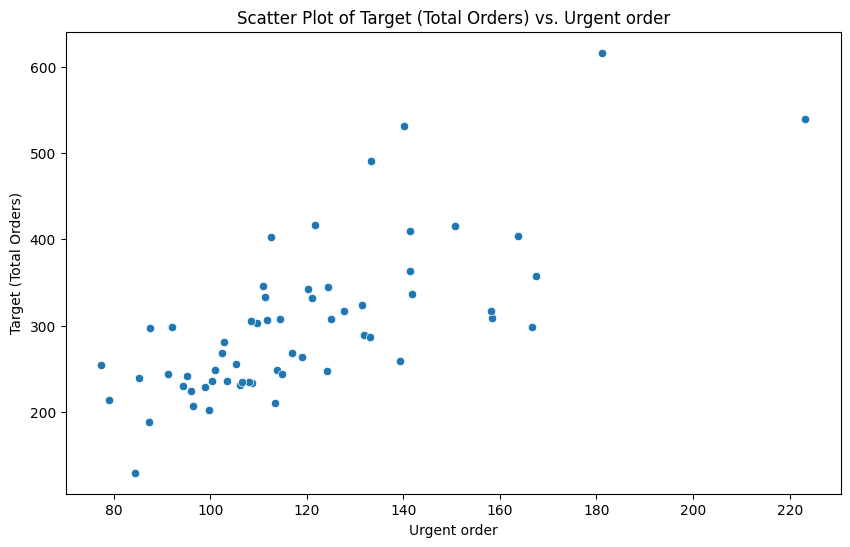

In [17]:
# Scatterplot: Total orders vs Urgent order
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Urgent order', y='Target (Total orders)', data=df)
plt.title('Scatter Plot of Target (Total Orders) vs. Urgent order')
plt.xlabel('Urgent order')
plt.ylabel('Target (Total Orders)')
plt.show()

Non‑urgent order is strongly correlated with total orders and also with Order type B, Order type C, and Banking orders (2), which suggests overlapping information.

Therefore, we only select **Non-urgent and Urgent order** columns along with **Day of the week** column for building the initial model.

## 3. Linear Model




### 3.1 Feature engineering and selection

In [18]:
# One-hot encode day-of-week for use in the linear model
df_encoded = pd.get_dummies(df, columns=['Day of the week (Monday to Friday)'], prefix='Day')
for col in df_encoded.columns:
    if col.startswith('Day_'):
        df_encoded[col] = df_encoded[col].astype(int)
# Display the first few rows of the DataFrame with encoded columns
display(df_encoded.head())

,"Week of the month (first week, second, third, fourth or fifth week",Non-urgent order,Urgent order,Order type A,Order type B,Order type C,Fiscal sector orders,Orders from the traffic controller sector,Banking orders (1),Banking orders (2),Banking orders (3),Target (Total orders),Day_2,Day_3,Day_4,Day_5,Day_6
0,1,316.307,223.270,61.543,175.586,302.448,0.000,65556,44914,188411,14793,539.577,0,0,1,0,0
1,1,128.633,96.042,38.058,56.037,130.580,0.000,40419,21399,89461,7679,224.675,0,0,0,1,0
2,1,43.651,84.375,21.826,25.125,82.461,1.386,11992,3452,21305,14947,129.412,0,0,0,0,1
3,2,171.297,127.667,41.542,113.294,162.284,18.156,49971,33703,69054,18423,317.120,1,0,0,0,0
4,2,90.532,113.526,37.679,56.618,116.220,6.459,48534,19646,16411,20257,210.517,0,1,0,0,0


In [19]:
# Keep only selected predictors and target for modeling
# Define the list of columns to keep
columns_to_keep = ['Non-urgent order', 'Urgent order', 'Target (Total orders)', 'Day_2', 'Day_3', 'Day_4', 'Day_5']

# Create the new DataFrame with only the specified columns
df_model = df_encoded[columns_to_keep].copy()

# Display the first few rows of the new model DataFrame
display(df_model.head())

,Non-urgent order,Urgent order,Target (Total orders),Day_2,Day_3,Day_4,Day_5
0,316.307,223.270,539.577,0,0,1,0
1,128.633,96.042,224.675,0,0,0,1
2,43.651,84.375,129.412,0,0,0,0
3,171.297,127.667,317.120,1,0,0,0
4,90.532,113.526,210.517,0,1,0,0


### 3.2 Test-Train split (80/20)

In [20]:
# Define features (X) and target (y)
X = df_model.drop('Target (Total orders)', axis=1)
y = df_model['Target (Total orders)']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (48, 6)
Shape of X_test: (12, 6)
Shape of y_train: (48,)
Shape of y_test: (12,)


## 3.3 Initial linear model: full specification
We first estimate a full linear model including day-of-week dummies to assess their incremental contribution alongside Non‑urgent and Urgent orders.

In [21]:
# Create a DataFrame for the OLS model using only the training data
train_df_for_ols = pd.concat([X_train, y_train], axis=1)

# Construct the formula using the column names from X_train and y_train
formula = f'Q("{y_train.name}") ~ {" + ".join([f"Q(\"{col}\")" if " " in col else col for col in X_train.columns])}'

# Initialize and fit the OLS model on the training data
ols_model = smf.ols(formula, data=train_df_for_ols).fit()

# Print the model summary
display(ols_model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                                
======================================================================================
Dep. Variable:     Q("Target (Total orders)")   R-squared:                       0.988
Model:                                    OLS   Adj. R-squared:                  0.986
Method:                         Least Squares   F-statistic:                     568.4
Date:                        Sat, 28 Mar 2026   Prob (F-statistic):           8.08e-38
Time:                                23:10:28   Log-Likelihood:                -172.87
No. Observations:                          48   AIC:                             359.7
Df Residuals:                              41   BIC:                             372.8
Df Model:                                   6                                         
Covariance Type:                    nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                12.4157      8.301      1.496      0.142      -4.349      29.180
Q("Non-urgent order")     1.0274      0.027     38.496      0.000       0.973       1.081
Q("Urgent order")         0.9642      0.084     11.529      0.000       0.795       1.133
Day_2                    -0.6952      5.749     -0.121      0.904     -12.305      10.914
Day_3                   -10.6879      4.670     -2.288      0.027     -20.120      -1.256
Day_4                   -11.3044      4.413     -2.562      0.014     -20.216      -2.393
Day_5                    -2.8287      4.339     -0.652      0.518     -11.591       5.934
==============================================================================
Omnibus:                       40.083   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              182.200
Skew:                           1.987   Prob(JB):                     2.73e-40
Kurtosis:                      11.678   Cond. No.                     1.35e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.35e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [22]:
# Compute predicted values
y_pred = ols_model.predict(X_test)

# Compute residuals on the test set
residuals = y_test - y_pred
print("Residuals:")
print(residuals)

# Compute RMSE on the test set
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nRoot Mean Squared Error (RMSE): {rmse:.2f}")

# Compute RMSPE on the test set
rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2))
print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.2f}")

Residuals:
0      -1.769578
5      -0.615863
36     -8.018268
45     -8.732287
13    -11.032316
54    -13.261693
33     -3.519250
48    160.424370
12     10.214874
57     -2.206464
46     -0.014453
50    -13.493843
dtype: float64

Root Mean Squared Error (RMSE): 46.98
Root Mean Squared Percentage Error (RMSPE): 0.12


For this initial linear specification, the model achieves an **RMSE of 46.98 and an RMSPE of 0.12** on the test set, indicating moderate predictive accuracy on this single split.

#### 3.31 Residual diagnostics

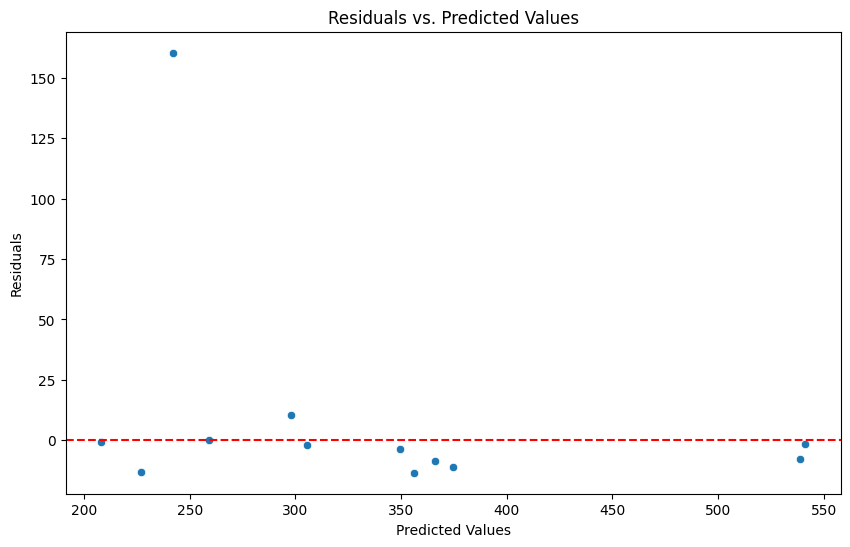

In [23]:
# Plot residuals vs predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

<Figure size 800x600 with 0 Axes>

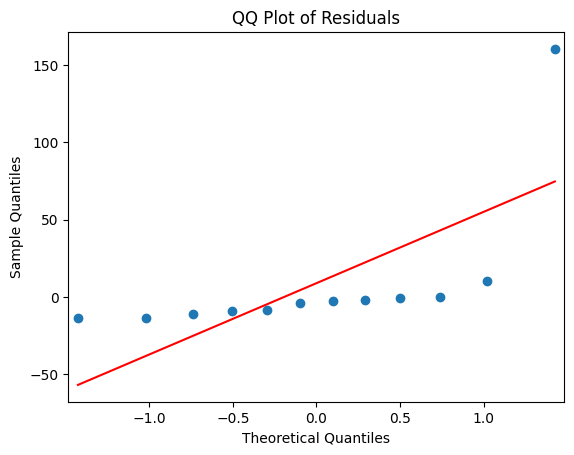

In [24]:
# QQ plot of residuals
plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='s')
plt.title('QQ Plot of Residuals')
plt.show()

Residual‑versus‑fitted and QQ plots do not reveal strong non‑linearity or heteroskedasticity, **so no log transformation of the predictors is required for this model**.

## 3.4 Linear model without day-of-week

In [25]:
# Drop day-of-week dummy columns from the feature set
columns_to_drop_days = [col for col in X_train.columns if col.startswith('Day_')]

X_train_new = X_train.drop(columns=columns_to_drop_days)
X_test_new = X_test.drop(columns=columns_to_drop_days)
y_train_new = y_train  # Target remains the same
y_test_new = y_test    # Target remains the same

print(f"Shape of X_train_new: {X_train_new.shape}")
print(f"Shape of X_test_new: {X_test_new.shape}")

Shape of X_train_new: (48, 2)
Shape of X_test_new: (12, 2)


In [26]:
# Build training DataFrame for the reduced OLS model
train_df_for_ols_new = pd.concat([X_train_new, y_train_new], axis=1)

# Construct the formula using the column names from X_train_new and y_train_new
formula_new = f'Q("{y_train_new.name}") ~ {" + ".join([f"Q(\"{col}\")" if " " in col else col for col in X_train_new.columns])}'

# Fit the reduced OLS model on the new training data
ols_model_new = smf.ols(formula_new, data=train_df_for_ols_new).fit()

# Print the model summary
display(ols_model_new.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                                
======================================================================================
Dep. Variable:     Q("Target (Total orders)")   R-squared:                       0.985
Model:                                    OLS   Adj. R-squared:                  0.984
Method:                         Least Squares   F-statistic:                     1433.
Date:                        Sat, 28 Mar 2026   Prob (F-statistic):           1.79e-41
Time:                                23:10:29   Log-Likelihood:                -179.18
No. Observations:                          48   AIC:                             364.4
Df Residuals:                              45   BIC:                             370.0
Df Model:                                   2                                         
Covariance Type:                    nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 7.1991      7.643      0.942      0.351      -8.195      22.593
Q("Non-urgent order")     1.0330      0.028     36.934      0.000       0.977       1.089
Q("Urgent order")         0.9552      0.077     12.443      0.000       0.801       1.110
==============================================================================
Omnibus:                       38.789   Durbin-Watson:                   2.413
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              129.533
Skew:                           2.103   Prob(JB):                     7.45e-29
Kurtosis:                       9.862   Cond. No.                     1.07e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.07e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [27]:
# Compute predicted values using reduced OLS model
y_pred_new = ols_model_new.predict(X_test_new)

# Compute residuals for the reduced model on the test set
residuals_new = y_test_new - y_pred_new
print("Residuals for new linear model:")
print(residuals_new)

# Calculate RMSE for the new model
rmse_new = np.sqrt(mean_squared_error(y_test_new, y_pred_new))
print(f"\nRoot Mean Squared Error (RMSE) for new linear model: {rmse_new:.2f}")

# Calculate RMSPE for the new model
rmspe_new = np.sqrt(np.mean(((y_test_new - y_pred_new) / y_test_new) ** 2))
print(f"Root Mean Squared Percentage Error (RMSPE) for new linear model: {rmspe_new:.2f}")

Residuals for new linear model:
0      -7.653940
5      -6.471264
36     -4.405885
45     -3.778845
13     -6.495169
54     -8.099611
33     -9.947211
48    163.135649
12     15.487790
57     -8.410422
46     -4.920003
50     -9.155724
dtype: float64

Root Mean Squared Error (RMSE) for new linear model: 47.76
Root Mean Squared Percentage Error (RMSPE) for new linear model: 0.12


Dropping the day‑of‑week dummies leaves RMSE, RMSPE, and R‑squared virtually unchanged, suggesting that day‑of‑week adds limited incremental predictive value and can be excluded from the final specification.

## 3.6 Linear model – 1000 iterations


To assess out-of-sample performance robustly, we repeat the 80/20 train–test split 1000 times, refit the model on each training set, and record RMSE and RMSPE on each test set.

In [28]:
n_iterations = 1000
rmse_scores = []
rmspe_scores = []

# Define the features and target for the linear model
features_for_loop = ['Non-urgent order', 'Urgent order']
target_for_loop = 'Target (Total orders)'

X_loop = df[features_for_loop]
y_loop = df[target_for_loop]

for i in range(n_iterations):
    # 1. Create a test-train (80:20) split
    X_train_loop, X_test_loop, y_train_loop, y_test_loop = train_test_split(X_loop, y_loop, test_size=0.2, random_state=None) # random_state=None for different splits

    # Create a DataFrame for the OLS model using the training data of the current iteration
    train_df_for_ols_loop = pd.concat([X_train_loop, y_train_loop], axis=1)

    # Construct the formula for the OLS model
    formula_loop = f'Q("{y_train_loop.name}") ~ {" + ".join([f"Q(\"{col}\")" if " " in col else col for col in X_train_loop.columns])}'

    # 2. Train the OLS model
    ols_model_loop = smf.ols(formula_loop, data=train_df_for_ols_loop).fit()

    # 3. Predict on the test set
    y_pred_loop = ols_model_loop.predict(X_test_loop)

    # 4. Compute RMSE and RMSPE
    rmse_loop = np.sqrt(mean_squared_error(y_test_loop, y_pred_loop))
    rmspe_loop = np.sqrt(np.mean(((y_test_loop - y_pred_loop) / y_test_loop) ** 2))

    # 5. Store the metrics
    rmse_scores.append(rmse_loop)
    rmspe_scores.append(rmspe_loop)

print(f"Finished {n_iterations} iterations.\n")
print(f"Mean RMSE over {n_iterations} iterations: {np.mean(rmse_scores):.2f}")
print(f"Standard Deviation of RMSE: {np.std(rmse_scores):.2f}")
print(f"Mean RMSPE over {n_iterations} iterations: {np.mean(rmspe_scores):.2f}")
print(f"Standard Deviation of RMSPE: {np.std(rmspe_scores):.2f}")

Finished 1000 iterations.

Mean RMSE over 1000 iterations: 18.68
Standard Deviation of RMSE: 15.58
Mean RMSPE over 1000 iterations: 0.05
Standard Deviation of RMSPE: 0.03


Using only Non‑urgent and Urgent orders as predictors, the linear model achieves a **mean RMSE of 18.68 (SD 15.58) and a mean RMSPE of 0.05 (SD 0.03)** over 1000 random 80/20 splits, indicating low average relative forecast error.

## 4. Random Forest Model

### 4.1 Random Forest feature importance (all variables)

We use this model to assess relative feature importance.

In [29]:
# Define features X and target y for Random Forest feature-importance model
X_rf = df.drop('Target (Total orders)', axis=1)
y_rf = df['Target (Total orders)']

# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=4, min_samples_leaf=4)

# Fit Random Forest on the full dataset for feature importance
rf_model.fit(X_rf, y_rf)

print("Random Forest Model trained successfully.")

Random Forest Model trained successfully.


In [30]:
# Get feature importances
feature_importances = rf_model.feature_importances_

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': X_rf.columns,
    'Importance': feature_importances
})

# Sort features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the sorted feature importances
display(feature_importance_df)

,Feature,Importance
2,Non-urgent order,0.518286
5,Order type B,0.360965
6,Order type C,0.062890
10,Banking orders (2),0.025787
3,Urgent order,0.013718
1,Day of the week (Monday to Friday),0.004789
9,Banking orders (1),0.003254
8,Orders from the traffic controller sector,0.003025
4,Order type A,0.002870
11,Banking orders (3),0.002639


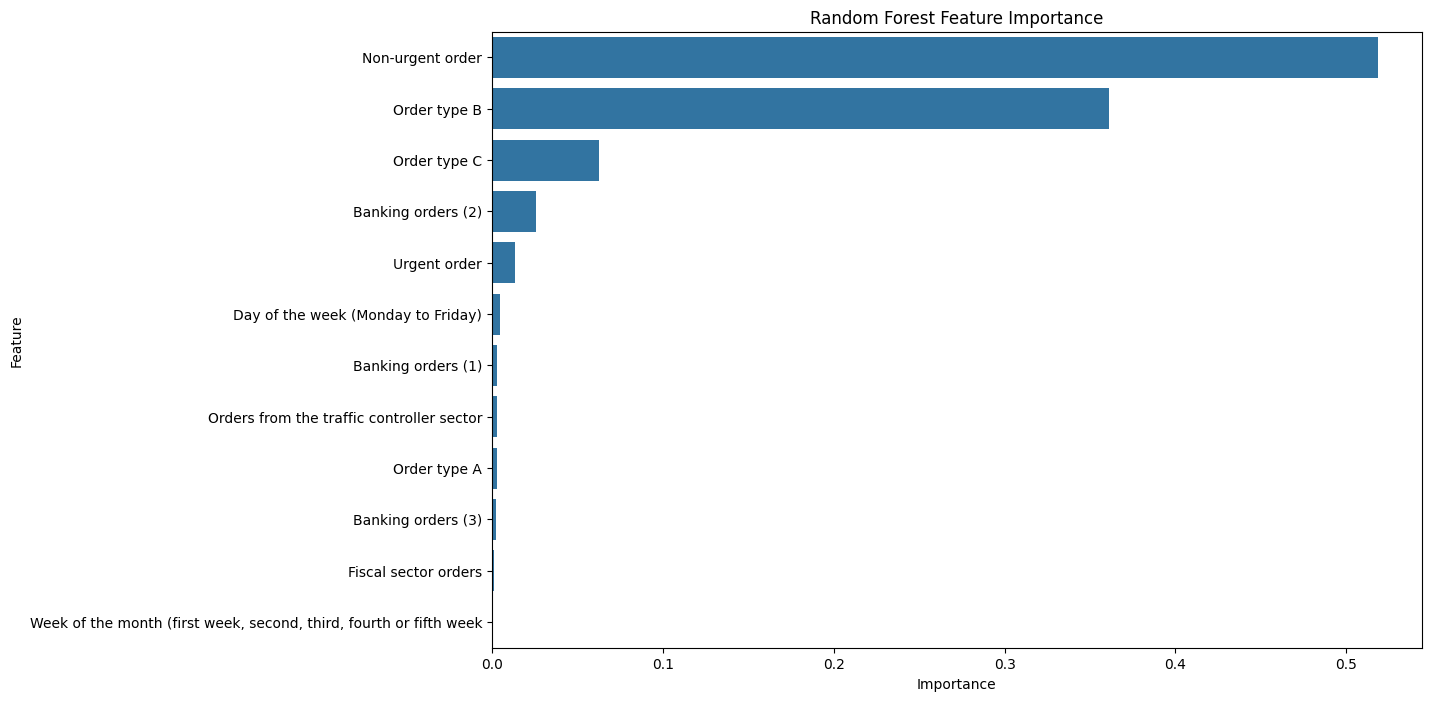

In [31]:
# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

The Random Forest feature importance results confirm that Non‑urgent order, together with Order types B and C and Banking orders (2), carry most of the predictive signal for total orders, consistent with the earlier correlation analysis.

## 4.2 Random Forest model with selected predictors
We now restrict the Random Forest to the two key predictors (Non‑urgent and Urgent orders) to make it comparable to the linear model.

In [32]:
# Select relevant columns for the new Random Forest model
rf_model_data = df[['Non-urgent order', 'Urgent order', 'Target (Total orders)']].copy()

# Define features (X) and target (y)
X_rf_split = rf_model_data.drop('Target (Total orders)', axis=1)
y_rf_split = rf_model_data['Target (Total orders)']

# Split the data into training and testing sets (80% train, 20% test)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf_split, y_rf_split, test_size=0.2, random_state=42)

# Initialize the Random Forest Regressor model
rf_model_split = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=4, min_samples_leaf=4)

# Fit the model on the training data
rf_model_split.fit(X_train_rf, y_train_rf)

print("Random Forest Model trained successfully on the training set with specified features.")
print(f"Shape of X_train_rf: {X_train_rf.shape}")
print(f"Shape of X_test_rf: {X_test_rf.shape}")

Random Forest Model trained successfully on the training set with specified features.
Shape of X_train_rf: (48, 2)
Shape of X_test_rf: (12, 2)


In [33]:
# Make predictions on the test set using the trained Random Forest model
y_pred_rf = rf_model_split.predict(X_test_rf)

# Calculate RMSE and RMSPE
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))

print(f"Root Mean Squared Error (RMSE) for Random Forest Model: {rmse_rf:.2f}")

rmspe_rf = np.sqrt(np.mean(((y_test_rf - y_pred_rf) / y_test_rf) ** 2))
print(f"Root Mean Squared Percentage Error (RMSPE) for Random Forest Model: {rmspe_rf:.2f}")

Root Mean Squared Error (RMSE) for Random Forest Model: 65.25
Root Mean Squared Percentage Error (RMSPE) for Random Forest Model: 0.16


On a single 80/20 split, the Random Forest model with Non‑urgent and Urgent orders yields an RMSE of 65.25 and an RMSPE of 0.16, **which is weaker than the comparable linear model performance on this split.**

### 4.21 Random Forest – 1000 iterations
To assess out-of-sample performance robustly, we repeat the 80/20 train–test split 1000 times, refit the model on each training set, and record RMSE and RMSPE on each test set.


In [34]:
n_iterations_rf = 1000
rmse_scores_rf = []
rmspe_scores_rf = []

# Define the features and target for the Random Forest model
features_for_rf_loop = ['Non-urgent order', 'Urgent order']
target_for_rf_loop = 'Target (Total orders)'

X_rf_loop = df[features_for_rf_loop]
y_rf_loop = df[target_for_rf_loop]

for i in range(n_iterations_rf):
    # 1. Create a test-train (80:20) split
    X_train_rf_loop, X_test_rf_loop, y_train_rf_loop, y_test_rf_loop = train_test_split(X_rf_loop, y_rf_loop, test_size=0.2, random_state=None) # random_state=None for different splits

    # 2. Initialize and train the Random Forest Regressor model
    rf_model_loop = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=4, min_samples_leaf=4)
    rf_model_loop.fit(X_train_rf_loop, y_train_rf_loop)

    # 3. Predict on the test set
    y_pred_rf_loop = rf_model_loop.predict(X_test_rf_loop)

    # 4. Compute RMSE and RMSPE
    rmse_rf_loop = np.sqrt(mean_squared_error(y_test_rf_loop, y_pred_rf_loop))
    rmspe_rf_loop = np.sqrt(np.mean(((y_test_rf_loop - y_pred_rf_loop) / y_test_rf_loop) ** 2))

    # 5. Store the metrics
    rmse_scores_rf.append(rmse_rf_loop)
    rmspe_scores_rf.append(rmspe_rf_loop)

print(f"Finished {n_iterations_rf} iterations for Random Forest model.\n")
print(f"Mean RMSE over {n_iterations_rf} iterations (RF): {np.mean(rmse_scores_rf):.2f}")
print(f"Standard Deviation of RMSE (RF): {np.std(rmse_scores_rf):.2f}")
print(f"Mean RMSPE over {n_iterations_rf} iterations (RF): {np.mean(rmspe_scores_rf):.2f}")
print(f"Standard Deviation of RMSPE (RF): {np.std(rmspe_scores_rf):.2f}")

Finished 1000 iterations for Random Forest model.

Mean RMSE over 1000 iterations (RF): 40.58
Standard Deviation of RMSE (RF): 16.89
Mean RMSPE over 1000 iterations (RF): 0.13
Standard Deviation of RMSPE (RF): 0.06


With Non‑urgent and Urgent orders as inputs, the Random Forest model attains a **mean RMSE of 40.58 (SD 16.89) and a mean RMSPE of 0.13 (SD 0.06)** over 1000 random 80/20 splits, implying higher typical error and variability than the linear model.

## 5. Model Comparison

In [35]:
# Calculate mean and standard deviation for Linear Model (OLS)
mean_rmse_ols = np.mean(rmse_scores)
std_rmse_ols = np.std(rmse_scores)
mean_rmspe_ols = np.mean(rmspe_scores)
std_rmspe_ols = np.std(rmspe_scores)

# Calculate mean and standard deviation for Random Forest Model
mean_rmse_rf = np.mean(rmse_scores_rf)
std_rmse_rf = np.std(rmse_scores_rf)
mean_rmspe_rf = np.mean(rmspe_scores_rf)
std_rmspe_rf = np.std(rmspe_scores_rf)

# Create a summary table comparing linear and RF models
comparison_data = {
    'Metric': ['RMSE (Mean)', 'RMSE (Std Dev)', 'RMSPE (Mean)', 'RMSPE (Std Dev)'],
    'Linear Model': [mean_rmse_ols, std_rmse_ols, mean_rmspe_ols, std_rmspe_ols],
    'Random Forest Model': [mean_rmse_rf, std_rmse_rf, mean_rmspe_rf, std_rmspe_rf]
}

comparison_df = pd.DataFrame(comparison_data)

# Display the table, formatting to 2 decimal places for better readability
display(comparison_df.round(2))

,Metric,Linear Model,Random Forest Model
0,RMSE (Mean),18.68,40.58
1,RMSE (Std Dev),15.58,16.89
2,RMSPE (Mean),0.05,0.13
3,RMSPE (Std Dev),0.03,0.06


Across 1000 random 80/20 splits, the linear model consistently outperforms the Random Forest on both RMSE and RMSPE. **The linear specification with Non‑urgent and Urgent orders therefore offers the best balance of predictive accuracy, stability, and interpretability for this dataset.**